# Predictive Model Training Using Historical Data (2015–2023)
## Objective
The objective of this phase is to develop a high-performance predictive model using historical financial market data from 2015 to 2023. The trained model serves as the baseline model for real-time market prediction and decision support.

**Key objectives include:**
- Build a robust predictive model capable of forecasting stock movement direction based on financial and company-related indicators.
- Leverage historical data to learn long-term market patterns and company-specific behavior.
- Deploy the best-performing model as the production model for real-time inference.
- Continuously monitor model performance using incoming real-time data.
- Automatically retrain and fine-tune the model when performance degradation or concept drift is detected.

## Data Sources
**Historical data includes:**
- Trade Date
- Company
- R&D Spending
- Revenue
- Revenue Growth
- Company Events
- Stock Impact

**Feature engineering generates additional predictive features:**
- Company Encoding
- Event Flag
- R&D Efficiency
- Stock Impact Lag Features (1-day, 7-day)
- Revenue Lag Features (1-day, 7-day)
- Rolling Moving Averages
- Company-specific historical trends

## Modelling
The following machine learning algorithms are evaluated during the offline training phase:

### **Baseline Models**
- Logistic Regression
- Decision Tree Classifier

### **Ensemble Models**
- Random Forest Classifier
- Gradient Boosting Classifier
- Extra Trees Classifier

### **Advanced Models (Optional)**
- XGBoost
- LightGBM

The model with the best validation performance is selected and registered as the production model.

## Training Strategy
### Offline Training
Historical data from 2015–2023 is used to train the initial model.

Historical Dataset
        ↓
Feature Engineering
        ↓
Model Training
        ↓
Model Evaluation
        ↓
Model Registry

### Real-Time Prediction
The deployed model generates predictions on streaming financial data without retraining.

Kafka Stream
        ↓
Spark Streaming
        ↓
Feature Generation
        ↓
Prediction Service
        ↓
PostgreSQL

### Continuous Learning
The model is periodically retrained using newly accumulated data.

Historical Data
+
Recent Streaming Data
        ↓
Retraining Pipeline
        ↓
Model Evaluation
        ↓
Model Promotion

**Retraining** is **automatically triggered** when model performance falls **below** predefined thresholds.

## Evaluation
The predictive models are evaluated using the following metrics:

### **Classification Metrics**
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

### **Confusion Matrix Analysis**
- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

## **Business-Oriented Metrics**
- Prediction Confidence Score
- Company-Level Prediction Accuracy
- Rolling 30-Day Model Performance
- Model Drift Detection

## Model Governance
To ensure reliability in production:
- Every trained model is assigned a unique model version.
- Performance metrics are stored in PostgreSQL.
- Historical model performance is tracked over time.
- New models are promoted only if they outperform the currently deployed model.
- Prediction results are fully traceable to the model version that generated them.

## Expected Outcome
The final system provides:
- Real-time stock movement prediction
- Automated model monitoring
- Continuous model improvement
- End-to-end MLOps workflow using Kafka, Spark, PostgreSQL, Airflow, Scikit-Learn, and Metabase

This architecture combines **offline historical learning** with **online real-time prediction**, allowing the model to benefit from both long-term market knowledge and recent market behavior.

In [102]:
import pandas as pd 

df = pd.read_csv("data/historical_market_data.csv", parse_dates=["Date"])
df = df.rename(columns={
    "Company":"company",
    "R&D_Spending_USD_Mn":"spending",
    "AI_Revenue_USD_Mn":"revenue",
    "AI_Revenue_Growth_%":"revenue_growth",
    "Event":"event",
    "Stock_Impact_%":"stock_impact"
})
df.head()

,Date,company,spending,revenue,revenue_growth,event,stock_impact
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09


In [103]:
# Check for missing values
df.isnull().sum()

Date                 0
company              0
spending             0
revenue              0
revenue_growth       0
event             9659
stock_impact         0
dtype: int64

In [104]:
df["event"] = df["event"].fillna("No Event")
df.head()

,Date,company,spending,revenue,revenue_growth,event,stock_impact
0,2015-01-01,OpenAI,5.92,0.63,-36.82,No Event,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,No Event,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,No Event,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,No Event,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,No Event,-0.09


In [105]:
df_OpenAI = df[df["company"] == "OpenAI"]
df_Google = df[df["company"] == "Google"]
df_Meta = df[df["company"] == "Meta"]

Trend of Stock Impact

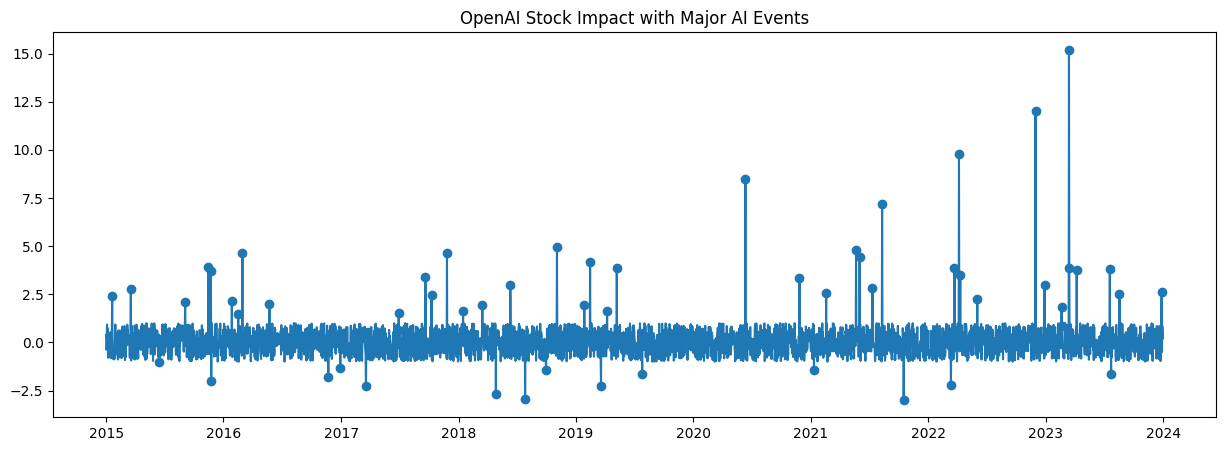

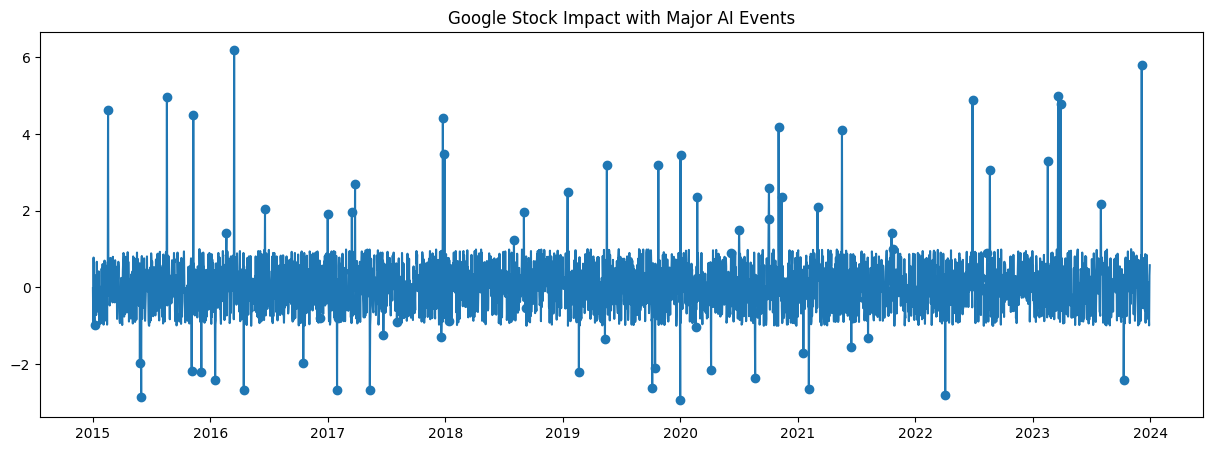

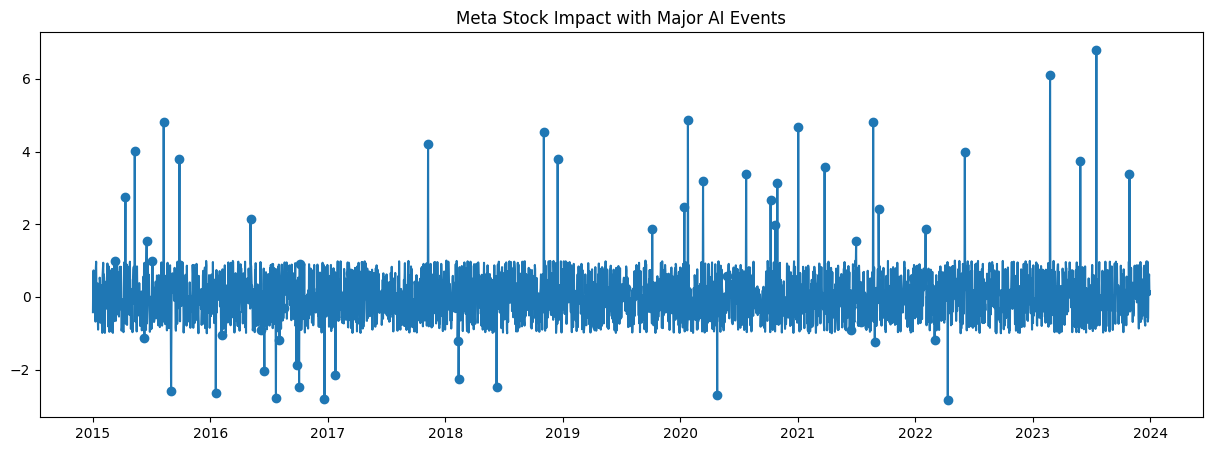

In [106]:
import matplotlib.pyplot as plt

company = ["OpenAI", "Google", "Meta"]

for i in company:
    plt.figure(figsize=(15,5))
    
    com_dat = df[df["company"] == i]
    
    plt.plot(
        com_dat["Date"],
        com_dat["stock_impact"],
        label="Stock Impact"
    )
    
    event_df = df[df["event"] != "No Event"]
    
    plt.scatter(
        com_dat[com_dat["event"] != "No Event"]["Date"],
        com_dat[com_dat["event"] != "No Event"]["stock_impact"],
        marker="o"
    )
    
    plt.title(f"{i} Stock Impact with Major AI Events")
    plt.show()


All of the sudden spikes have event.

Impact of Events

In [107]:
df["event"].unique()

array(['No Event', 'Cloud AI launch', 'AI ethics policy update',
       'AI-powered search update', 'AI Ads Optimization upgrade',
       'AI partnership deal', 'AI Video Recommendation upgrade',
       'AI speech recognition release', 'GPT-1 release', 'GPT-2 release',
       'GPT-3 release', 'Codex release', 'DALL·E 2 release',
       'ChatGPT (GPT-3.5) launch', 'GPT-4 release',
       'TensorFlow open-source release', 'AlphaGo beats Lee Sedol',
       'BERT for Search launch', 'MUM Search Model launch',
       'Bard chatbot launch', 'Gemini AI release', 'LLaMA 1 release',
       'LLaMA 2 release'], dtype=object)

In [108]:
df[df["event"]!="No Event"].groupby("company").count().iloc[0:,4]

company
Google    73
Meta      64
OpenAI    65
Name: event, dtype: int64

In [109]:
# Average stock impact by event
event_impact = (
    df.groupby("event")["stock_impact"]
      .agg(["mean", "median", "std", "count"])
      .sort_values("mean", ascending=False)
)

print(event_impact)

                                      mean  median       std  count
event                                                              
GPT-4 release                    15.200000  15.200       NaN      1
ChatGPT (GPT-3.5) launch         12.000000  12.000       NaN      1
DALL·E 2 release                  9.800000   9.800       NaN      1
GPT-3 release                     8.500000   8.500       NaN      1
Codex release                     7.200000   7.200       NaN      1
LLaMA 2 release                   6.800000   6.800       NaN      1
AlphaGo beats Lee Sedol           6.200000   6.200       NaN      1
LLaMA 1 release                   6.100000   6.100       NaN      1
Gemini AI release                 5.800000   5.800       NaN      1
Bard chatbot launch               5.000000   5.000       NaN      1
TensorFlow open-source release    4.500000   4.500       NaN      1
GPT-2 release                     4.200000   4.200       NaN      1
MUM Search Model launch           4.100000   4.1

Launch of new product usually leads to stronger positive stock impact.

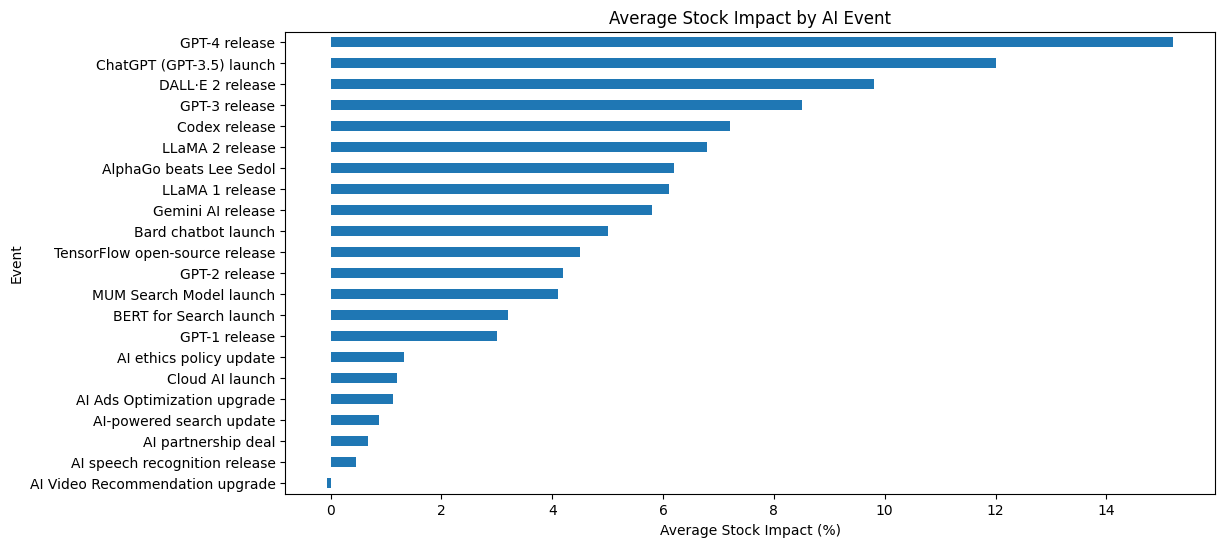

In [110]:
event_mean = (
    df[df["event"] != "No Event"]
    .groupby("event")["stock_impact"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,6))
event_mean.plot.barh()

plt.title("Average Stock Impact by AI Event")
plt.xlabel("Average Stock Impact (%)")
plt.ylabel("Event")
plt.show()

In [111]:
df["has_event"] = (df["event"] != "No Event").astype(int)

df.groupby("has_event")["stock_impact"].mean()

has_event
0   -0.000908
1    1.230198
Name: stock_impact, dtype: float64

Event days show higher impact than no event.

In [112]:
company_event = (
    df[df["event"] != "No Event"]
    .groupby(["company", "event"])["stock_impact"]
    .mean()
    .reset_index()
)

print(company_event.head())

  company                            event  stock_impact
0  Google      AI Ads Optimization upgrade      0.524444
1  Google  AI Video Recommendation upgrade     -0.996667
2  Google          AI ethics policy update      2.183750
3  Google              AI partnership deal      0.153571
4  Google    AI speech recognition release     -0.250000


In [113]:
OpenAI_event = (
    company_event[company_event["company"]=="OpenAI"]
    .reset_index(drop=True)
    .set_index("event")
    .drop(columns="company")
    .sort_values(by="stock_impact", ascending=True)
)

Google_event = (
    company_event[company_event["company"]=="Google"]
    .reset_index(drop=True)
    .set_index("event")
    .drop(columns="company")
    .sort_values(by="stock_impact", ascending=True)
)

Meta_event = (
    company_event[company_event["company"]=="Meta"]
    .reset_index(drop=True)
    .set_index("event")
    .drop(columns="company")
    .sort_values(by="stock_impact", ascending=True)
)

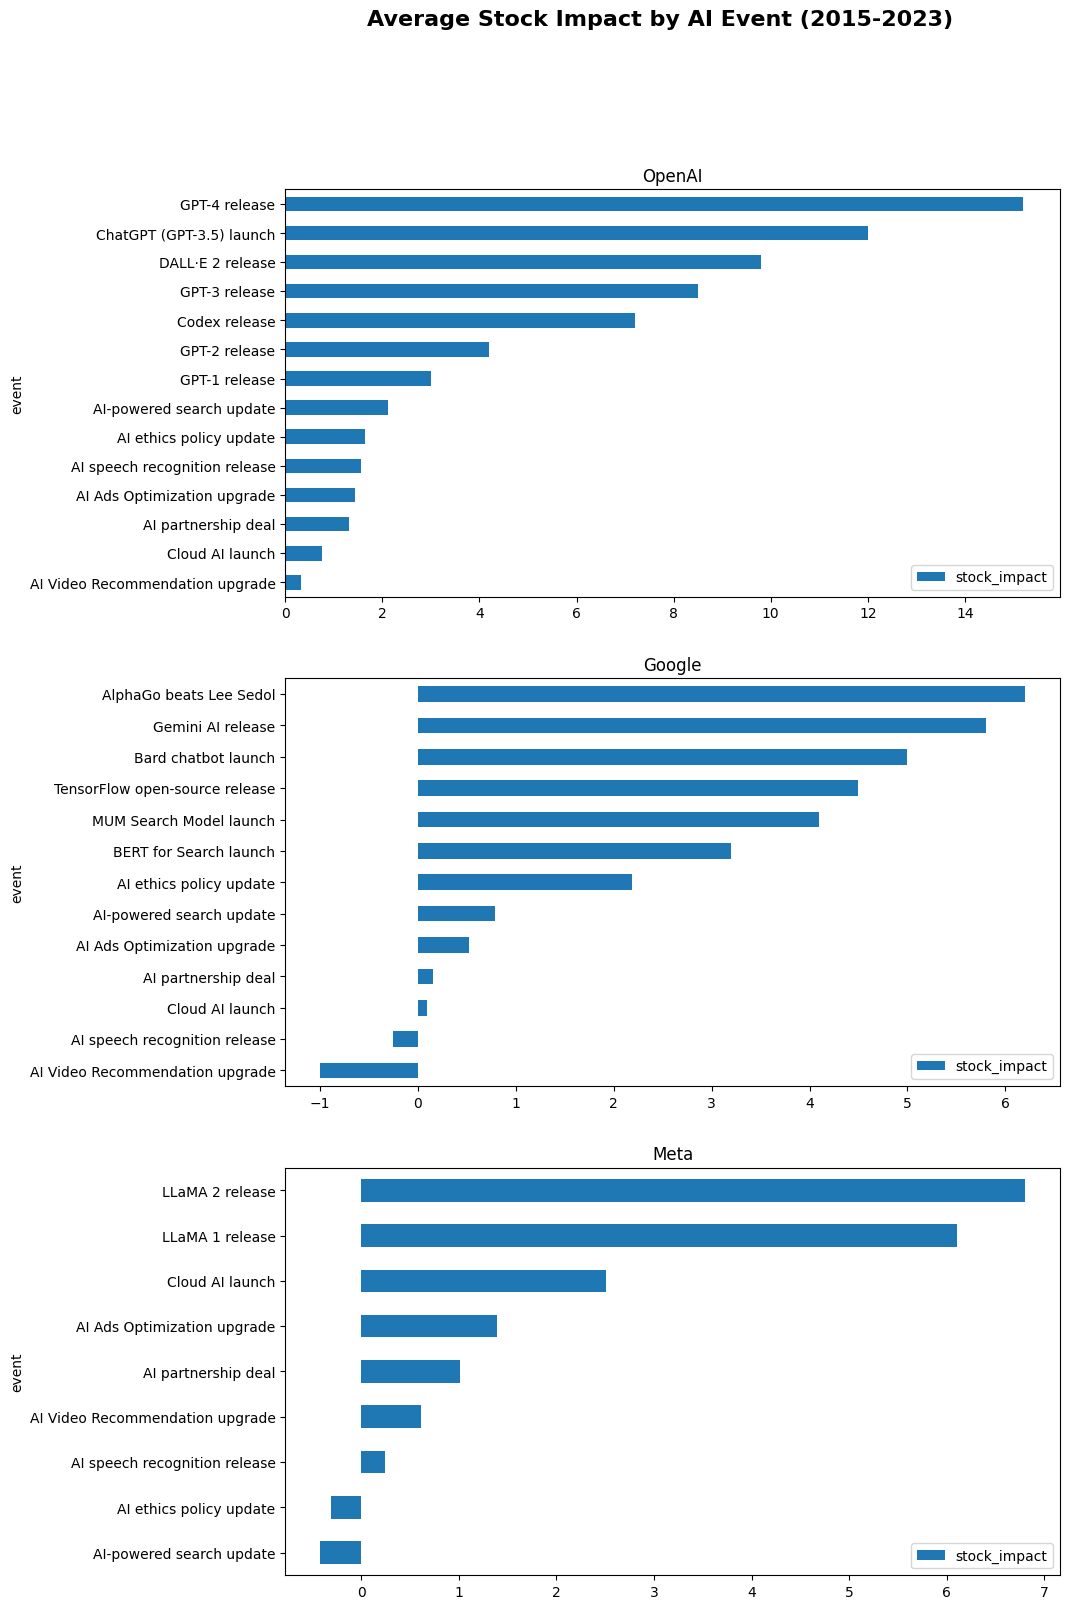

<Figure size 640x480 with 0 Axes>

In [114]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 18))

fig.suptitle(
    "Average Stock Impact by AI Event (2015-2023)",
    fontsize=16,
    fontweight="bold"
)

OpenAI_event.plot.barh(
    ax=axes[0], 
    title="OpenAI"
)

Google_event.plot.barh(
    ax=axes[1], 
    title="Google"
)

Meta_event.plot.barh(
    ax=axes[2], 
    title="Meta"
)

plt.show()
plt.tight_layout()
plt.show()

- OpenAI gets the largest boost from GPT releases.
- Google gets the largest boost from Gemini releases.
- Meta gets the largest boost from LLaMA releases.

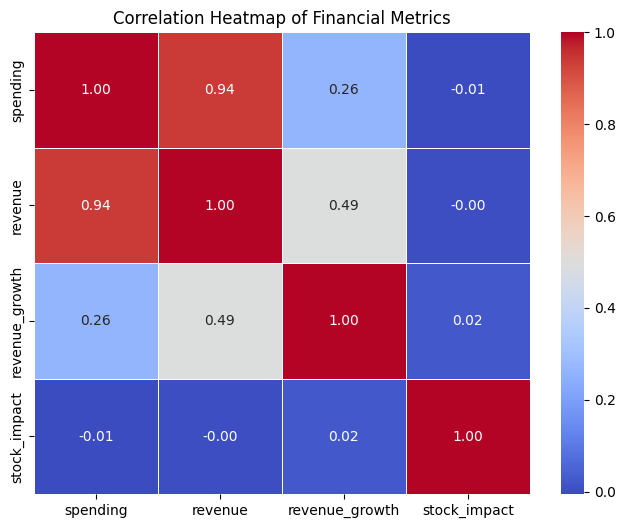

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[
    ["spending", "revenue", "revenue_growth", "stock_impact"]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Financial Metrics")
plt.show()

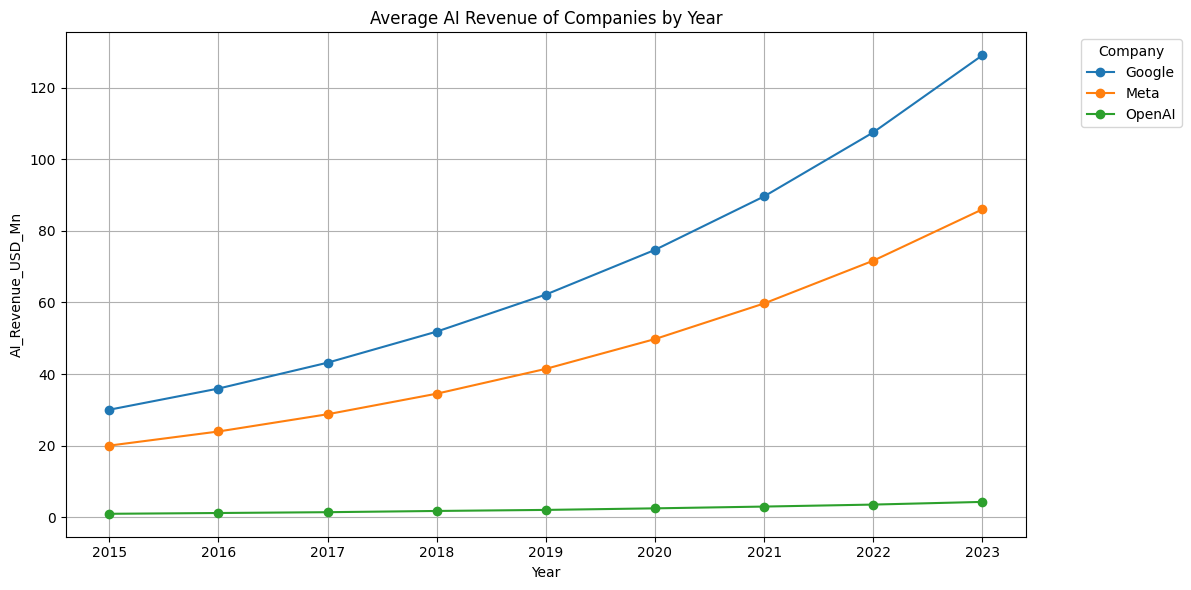

In [116]:
df['Year'] = df['Date'].dt.year
pivot = df.pivot_table(index='Year', columns='company', values='revenue', aggfunc='mean')

plt.figure(figsize=(12,6))
pivot.plot(marker='o', ax=plt.gca())  
plt.title("Average AI Revenue of Companies by Year")
plt.xlabel("Year")
plt.ylabel("AI_Revenue_USD_Mn")
plt.grid(True)
plt.legend(title="Company", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

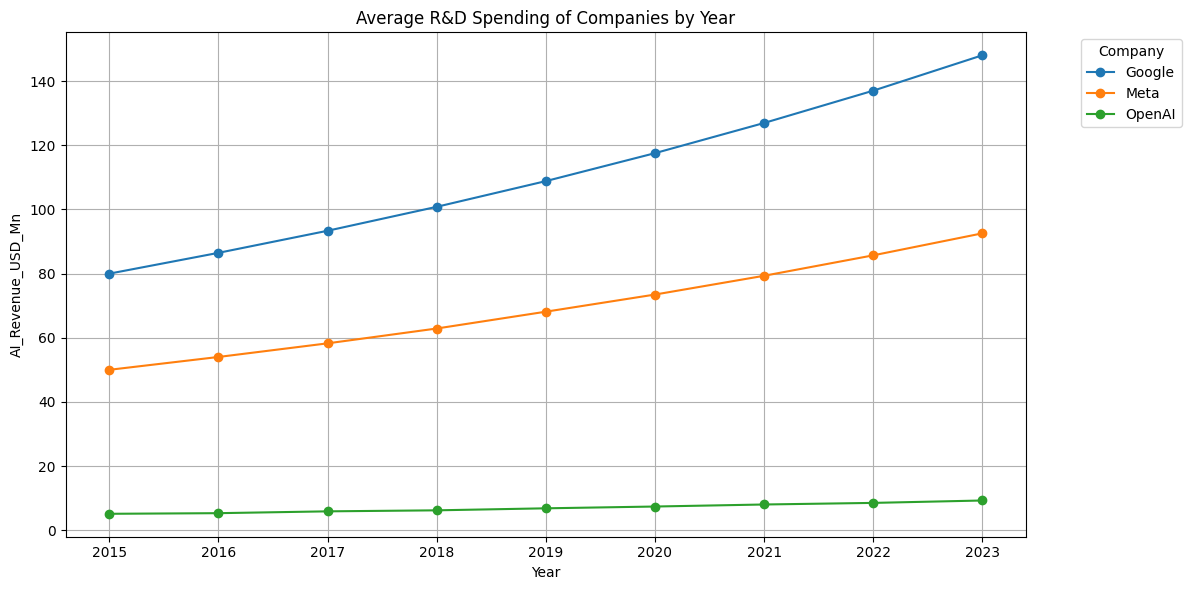

In [117]:
df['Year'] = df['Date'].dt.year
pivot = df.pivot_table(index='Year', columns='company', values='spending', aggfunc='mean')

plt.figure(figsize=(12,6))
pivot.plot(marker='o', ax=plt.gca())  
plt.title("Average R&D Spending of Companies by Year")
plt.xlabel("Year")
plt.ylabel("AI_Revenue_USD_Mn")
plt.grid(True)
plt.legend(title="Company", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

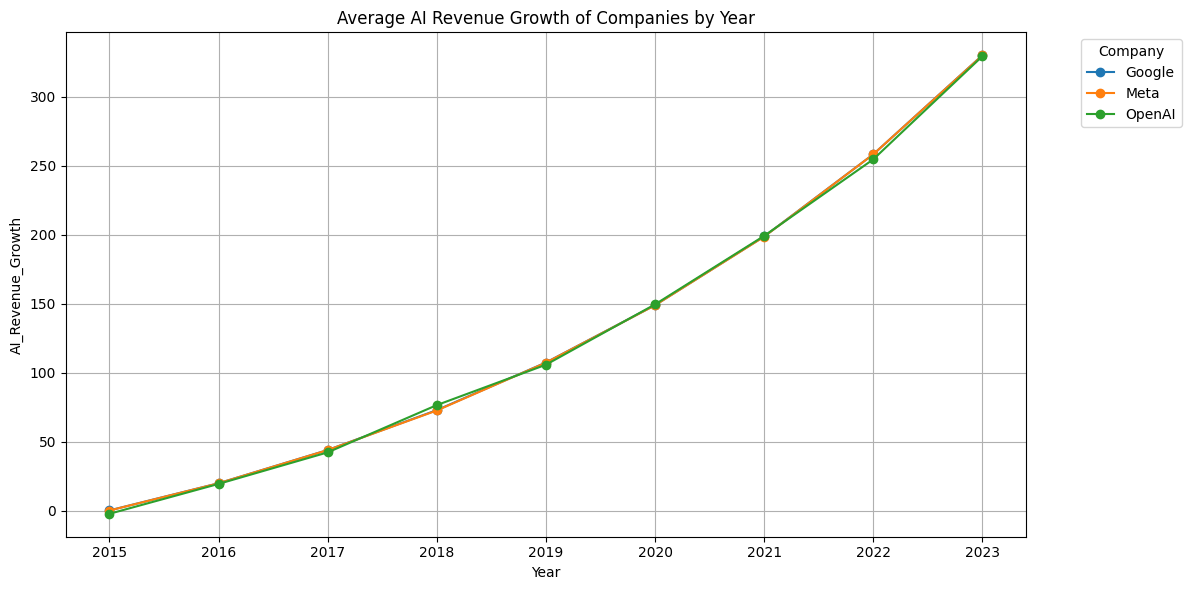

In [118]:
df['Year'] = df['Date'].dt.year
pivot = df.pivot_table(index='Year', columns='company', values='revenue_growth', aggfunc='mean')

plt.figure(figsize=(12,6))
pivot.plot(marker='o', ax=plt.gca())  
plt.title("Average AI Revenue Growth of Companies by Year")
plt.xlabel("Year")
plt.ylabel("AI_Revenue_Growth")
plt.grid(True)
plt.legend(title="Company", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

Feature engineering

In [119]:
df = df.sort_values(["company", "Date"])

for lag in [1, 3, 7, 14, 30]:
    df[f"stock_impact_lag_{lag}"] = (
        df.groupby("company")["stock_impact"]
          .shift(lag)
    )

In [120]:
df["stock_ma_7"] = (
    df.groupby("company")["stock_impact"]
      .transform(lambda x: x.rolling(7).mean())
)

df["stock_ma_14"] = (
    df.groupby("company")["stock_impact"]
      .transform(lambda x: x.rolling(14).mean())
)

df["stock_ma_30"] = (
    df.groupby("company")["stock_impact"]
      .transform(lambda x: x.rolling(30).mean())
)

df["stock_std_7"] = (
    df.groupby("company")["stock_impact"]
      .transform(lambda x: x.rolling(7).std())
)

df["stock_std_14"] = (
    df.groupby("company")["stock_impact"]
      .transform(lambda x: x.rolling(14).std())
)

df["stock_std_30"] = (
    df.groupby("company")["stock_impact"]
      .transform(lambda x: x.rolling(30).std())
)

In [121]:
# Growth of Spending and Revenue
df["spending_growth"] = (
    df.groupby("company")["spending"]
      .pct_change()
)

df["revenue_growth_daily"] = (
    df.groupby("company")["revenue"]
      .pct_change()
)

In [122]:
# Revenue Efficiency
df["revenue_per_spending"] = (
    df["revenue"] / df["spending"]
)       

# Momentum Features
df["revenue_momentum_7"] = (
    df.groupby("company")["revenue"]
      .diff(7)
)

df["spending_momentum_7"] = (
    df.groupby("company")["spending"]
      .diff(7)
)                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [125]:
# Days Since Last Event
df["days_since_event"] = (
    df.groupby("company")["has_event"]
      .transform(
          lambda x: x.groupby(x.eq(1).cumsum()).cumcount()
      )
)

In [126]:
# Calendar Features
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["quarter"] = df["Date"].dt.quarter
df["dayofweek"] = df["Date"].dt.dayofweek

In [127]:
df["revenue_x_growth"] = (
    df["revenue"] * df["revenue_growth"]
)

df["spending_x_growth"] = (
    df["spending"] * df["revenue_growth"]
)

In [128]:
# Event and Company (one-hot encoding)
df = pd.get_dummies(
    df,
    columns=["company", "event"],
    drop_first=True
)

In [129]:
df.head()

,Date,spending,revenue,revenue_growth,stock_impact,has_event,Year,stock_impact_lag_1,stock_impact_lag_3,stock_impact_lag_7,...,event_GPT-1 release,event_GPT-2 release,event_GPT-3 release,event_GPT-4 release,event_Gemini AI release,event_LLaMA 1 release,event_LLaMA 2 release,event_MUM Search Model launch,event_No Event,event_TensorFlow open-source release
3287,2015-01-01,79.89,30.19,0.64,-0.02,0,2015,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,True,False
3288,2015-01-02,78.99,30.44,1.47,-0.98,0,2015,-0.02,NaN,NaN,...,False,False,False,False,False,False,False,False,True,False
3289,2015-01-03,79.20,30.46,1.53,0.78,0,2015,-0.98,NaN,NaN,...,False,False,False,False,False,False,False,False,True,False
3290,2015-01-04,79.59,30.55,1.82,-0.41,0,2015,0.78,-0.02,NaN,...,False,False,False,False,False,False,False,False,True,False
3291,2015-01-05,81.50,30.59,1.97,-0.78,0,2015,-0.41,-0.98,NaN,...,False,False,False,False,False,False,False,False,True,False


In [130]:
df.isnull().sum().sort_values(ascending=False)

stock_impact_lag_30                      90
stock_std_30                             87
stock_ma_30                              87
stock_impact_lag_14                      42
stock_std_14                             39
stock_ma_14                              39
spending_momentum_7                      21
revenue_momentum_7                       21
stock_impact_lag_7                       21
stock_std_7                              18
stock_ma_7                               18
stock_impact_lag_3                        9
stock_impact_lag_1                        3
spending_growth                           3
revenue_growth_daily                      3
event_GPT-2 release                       0
event_Cloud AI launch                     0
event_ChatGPT (GPT-3.5) launch            0
event_Bard chatbot launch                 0
event_Codex release                       0
event_DALL·E 2 release                    0
event_BERT for Search launch              0
event_AlphaGo beats Lee Sedol   

In [131]:
df_model = df.dropna()

In [133]:
df_model.columns

Index(['Date', 'spending', 'revenue', 'revenue_growth', 'stock_impact',
       'has_event', 'Year', 'stock_impact_lag_1', 'stock_impact_lag_3',
       'stock_impact_lag_7', 'stock_impact_lag_14', 'stock_impact_lag_30',
       'stock_ma_7', 'stock_ma_14', 'stock_ma_30', 'stock_std_7',
       'stock_std_14', 'stock_std_30', 'spending_growth',
       'revenue_growth_daily', 'revenue_per_spending', 'revenue_momentum_7',
       'spending_momentum_7', 'days_since_event', 'year', 'month', 'quarter',
       'dayofweek', 'revenue_x_growth', 'spending_x_growth', 'company_Meta',
       'company_OpenAI', 'event_AI Video Recommendation upgrade',
       'event_AI ethics policy update', 'event_AI partnership deal',
       'event_AI speech recognition release', 'event_AI-powered search update',
       'event_AlphaGo beats Lee Sedol', 'event_BERT for Search launch',
       'event_Bard chatbot launch', 'event_ChatGPT (GPT-3.5) launch',
       'event_Cloud AI launch', 'event_Codex release',
       'event

In [136]:
df_model = df_model.drop(
    columns=["Year"]
)

In [137]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9771 entries, 3317 to 3286
Data columns (total 53 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Date                                   9771 non-null   datetime64[ns]
 1   spending                               9771 non-null   float64       
 2   revenue                                9771 non-null   float64       
 3   revenue_growth                         9771 non-null   float64       
 4   stock_impact                           9771 non-null   float64       
 5   has_event                              9771 non-null   int32         
 6   stock_impact_lag_1                     9771 non-null   float64       
 7   stock_impact_lag_3                     9771 non-null   float64       
 8   stock_impact_lag_7                     9771 non-null   float64       
 9   stock_impact_lag_14                    9771 non-null   float64   

Modelling

In [141]:
target = "stock_impact"

X = df_model.drop(columns=["stock_impact","Date"])
y = df_model[target]

print(X.shape)
print(X.columns.tolist())

(9771, 51)
['spending', 'revenue', 'revenue_growth', 'has_event', 'stock_impact_lag_1', 'stock_impact_lag_3', 'stock_impact_lag_7', 'stock_impact_lag_14', 'stock_impact_lag_30', 'stock_ma_7', 'stock_ma_14', 'stock_ma_30', 'stock_std_7', 'stock_std_14', 'stock_std_30', 'spending_growth', 'revenue_growth_daily', 'revenue_per_spending', 'revenue_momentum_7', 'spending_momentum_7', 'days_since_event', 'year', 'month', 'quarter', 'dayofweek', 'revenue_x_growth', 'spending_x_growth', 'company_Meta', 'company_OpenAI', 'event_AI Video Recommendation upgrade', 'event_AI ethics policy update', 'event_AI partnership deal', 'event_AI speech recognition release', 'event_AI-powered search update', 'event_AlphaGo beats Lee Sedol', 'event_BERT for Search launch', 'event_Bard chatbot launch', 'event_ChatGPT (GPT-3.5) launch', 'event_Cloud AI launch', 'event_Codex release', 'event_DALL·E 2 release', 'event_GPT-1 release', 'event_GPT-2 release', 'event_GPT-3 release', 'event_GPT-4 release', 'event_Gemini

In [143]:
# Train/ Test Split by Time
train_df = df_model[df_model["Date"] < "2023-01-01"]
test_df = df_model[df_model["Date"] >= "2023-01-01"]

X_train = train_df.drop(columns=["stock_impact","Date"])
y_train = train_df[target]

X_test = test_df.drop(columns=["stock_impact","Date"])
y_test = test_df[target]

print(X_train.shape)
print(X_test.shape)

(8676, 51)
(1095, 51)


Prediction Modelling
- Random Forest
- XGBoost
- LGBM

In [169]:
import numpy as np
import optuna

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [170]:
# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
# Define Objective Function
def objective(trial, model_name, X, y):

    if model_name == "RF":

        params = {
            "n_estimators": trial.suggest_int(
                "n_estimators", 100, 1000
            ),
            "max_depth": trial.suggest_int(
                "max_depth", 3, 20
            ),
            "min_samples_split": trial.suggest_int(
                "min_samples_split", 2, 20
            ),
            "min_samples_leaf": trial.suggest_int(
                "min_samples_leaf", 1, 10
            ),
            "random_state": 42,
            "n_jobs": -1
        }

        model = RandomForestRegressor(**params)

    elif model_name == "XGB":

        params = {
            "n_estimators": trial.suggest_int(
                "n_estimators", 100, 1000
            ),
            "max_depth": trial.suggest_int(
                "max_depth", 3, 10
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.01, 0.3, log=True
            ),
            "subsample": trial.suggest_float(
                "subsample", 0.6, 1.0
            ),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.6, 1.0
            ),
            "random_state": 42,
            "n_jobs": -1
        }

        model = XGBRegressor(**params)

    elif model_name == "LGBM":

        params = {
            "n_estimators": trial.suggest_int(
                "n_estimators", 100, 1000
            ),
            "max_depth": trial.suggest_int(
                "max_depth", 3, 10
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.01, 0.3, log=True
            ),
            "subsample": trial.suggest_float(
                "subsample", 0.6, 1.0
            ),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.6, 1.0
            ),
            "random_state": 42,
            "verbose": -1
        }

        model = LGBMRegressor(**params)

    mae_scores = []
    
    for train_idx, test_idx in tscv.split(X):

        X_train_fold = X.iloc[train_idx]
        X_test_fold = X.iloc[test_idx]

        y_train_fold = y.iloc[train_idx]
        y_test_fold = y.iloc[test_idx]

        model.fit(X_train_fold, y_train_fold)

        pred = model.predict(X_test_fold)

        mae_scores.append(
            mean_absolute_error(
                y_test_fold,
                pred
            )
        )


    return np.mean(mae_scores)

In [165]:
# Tune all models
results = {}

for model_name in ["RF", "XGB", "LGBM"]:

    print(f"\nOptimizing {model_name}...")

    study = optuna.create_study(
        direction="minimize"
    )

    study.optimize(
        lambda trial: objective(
            trial,
            model_name,
            X,
            y
        ),
        n_trials=50
    )

    results[model_name] = {
        "best_mae": study.best_value,
        "best_params": study.best_params
    }

[I 2026-06-11 13:12:07,945] A new study created in memory with name: no-name-9045413c-d3fb-4ab1-bb97-567e17207ca9



Optimizing RF...


[I 2026-06-11 13:12:15,546] Trial 0 finished with value: 0.4609595203353868 and parameters: {'n_estimators': 600, 'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.4609595203353868.
[I 2026-06-11 13:12:19,898] Trial 1 finished with value: 0.4613819012103759 and parameters: {'n_estimators': 337, 'max_depth': 7, 'min_samples_split': 19, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.4609595203353868.
[I 2026-06-11 13:12:39,477] Trial 2 finished with value: 0.46098352123645514 and parameters: {'n_estimators': 977, 'max_depth': 15, 'min_samples_split': 13, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.4609595203353868.
[I 2026-06-11 13:12:44,689] Trial 3 finished with value: 0.46980785653473617 and parameters: {'n_estimators': 661, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.4609595203353868.
[I 2026-06-11 13:13:02,026] Trial 4 finished with value: 0.4603059062723139 and parameters


Optimizing XGB...


[I 2026-06-11 13:18:12,771] Trial 0 finished with value: 0.4651983580624968 and parameters: {'n_estimators': 207, 'max_depth': 3, 'learning_rate': 0.06602884748221134, 'subsample': 0.6138037394969779, 'colsample_bytree': 0.8369940761582189}. Best is trial 0 with value: 0.4651983580624968.
[I 2026-06-11 13:18:14,251] Trial 1 finished with value: 0.4834186318854033 and parameters: {'n_estimators': 598, 'max_depth': 4, 'learning_rate': 0.11003990596014948, 'subsample': 0.9373204091015759, 'colsample_bytree': 0.6583196503458842}. Best is trial 0 with value: 0.4651983580624968.
[I 2026-06-11 13:18:18,878] Trial 2 finished with value: 0.4808016297587061 and parameters: {'n_estimators': 509, 'max_depth': 8, 'learning_rate': 0.10754243998017268, 'subsample': 0.6349237733462368, 'colsample_bytree': 0.905040201321827}. Best is trial 0 with value: 0.4651983580624968.
[I 2026-06-11 13:18:22,104] Trial 3 finished with value: 0.47165549424338965 and parameters: {'n_estimators': 488, 'max_depth': 7, 


Optimizing LGBM...


[I 2026-06-11 13:20:14,062] Trial 0 finished with value: 0.47763537993423455 and parameters: {'n_estimators': 629, 'max_depth': 5, 'learning_rate': 0.06519934029800402, 'subsample': 0.6022296471492314, 'colsample_bytree': 0.9839930008005519}. Best is trial 0 with value: 0.47763537993423455.
[I 2026-06-11 13:20:14,417] Trial 1 finished with value: 0.5007633303450181 and parameters: {'n_estimators': 258, 'max_depth': 5, 'learning_rate': 0.29883297745768816, 'subsample': 0.7091542844735066, 'colsample_bytree': 0.6307028730427848}. Best is trial 0 with value: 0.47763537993423455.
[I 2026-06-11 13:20:14,670] Trial 2 finished with value: 0.4732130295936822 and parameters: {'n_estimators': 152, 'max_depth': 5, 'learning_rate': 0.014350760505455692, 'subsample': 0.8564787172249257, 'colsample_bytree': 0.6802844921190949}. Best is trial 2 with value: 0.4732130295936822.
[I 2026-06-11 13:20:15,555] Trial 3 finished with value: 0.46477201142312435 and parameters: {'n_estimators': 377, 'max_depth'

In [167]:
# Compare Results
comparison = pd.DataFrame([
    {
        "Model": model,
        "MAE": results[model]["best_mae"]
    }
    for model in results
])

comparison = comparison.sort_values(
    by="MAE"
)

print(comparison)

  Model       MAE
0    RF  0.458228
1   XGB  0.459475
2  LGBM  0.462623


In [172]:
best_model_name = comparison.iloc[0]["Model"]

print(
    f"Best Model: {best_model_name}"
)

best_params = results[best_model_name]["best_params"]

print(
    f"Best Params: {best_params}"
)

Best Model: RF
Best Params: {'n_estimators': 329, 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 3}


In [174]:
# build the best model
model = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [175]:
# Evaluate
mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

r2 = r2_score(
    y_test,
    pred
)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 0.4653
RMSE: 0.6257
R²  : 0.5060


In [176]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance.head(20))

                 feature  importance
9             stock_ma_7    0.257146
3              has_event    0.173462
12           stock_std_7    0.129453
20      days_since_event    0.088438
13          stock_std_14    0.068734
49        event_No Event    0.063350
5     stock_impact_lag_3    0.039847
4     stock_impact_lag_1    0.039292
14          stock_std_30    0.014508
15       spending_growth    0.012731
7    stock_impact_lag_14    0.012654
19   spending_momentum_7    0.012132
8    stock_impact_lag_30    0.010308
10           stock_ma_14    0.009842
11           stock_ma_30    0.008708
6     stock_impact_lag_7    0.008376
18    revenue_momentum_7    0.007556
16  revenue_growth_daily    0.006940
0               spending    0.005471
2         revenue_growth    0.005363


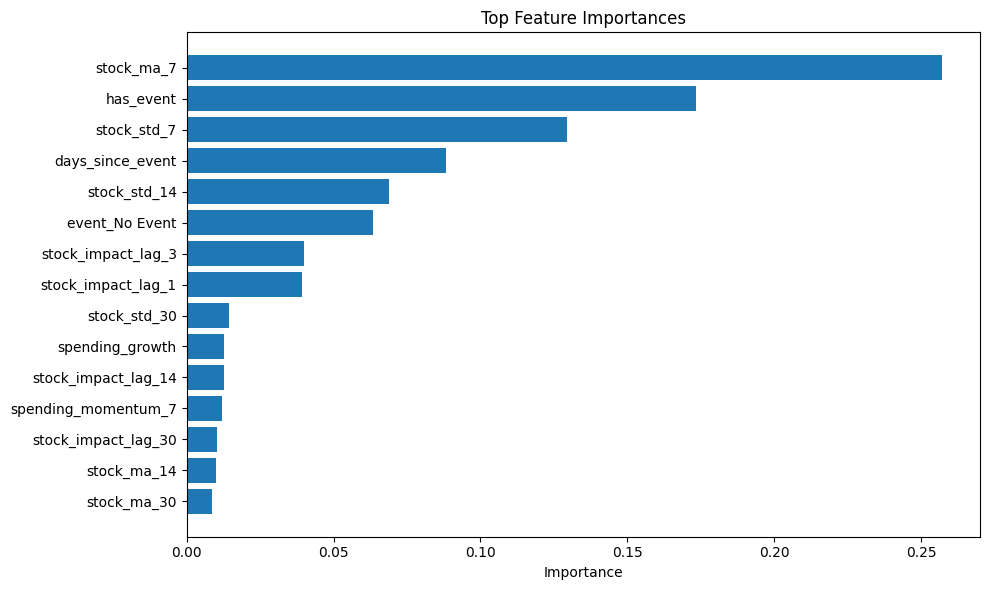

In [177]:
import matplotlib.pyplot as plt

top_n = 15

plt.figure(figsize=(10,6))

plt.barh(
    importance["feature"].head(top_n)[::-1],
    importance["importance"].head(top_n)[::-1]
)

plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

- The Random Forest model outperformed the ARIMA baseline by approximately 15% in predicting time-series stock impact. However, the overall predictive performance remains moderate, with MAE of 0.4653, RMSE of 0.6257, and an R² of 0.5060, indicating that the model explains around 50% of the variance in the target variable.
- The stock impact shows strong sensitivity to event occurrences, with noticeable spikes during event periods. This suggests that incorporating structured event-related features (e.g., event type, timing, and context) into the dataset could further improve predictive performance and better capture market reactions.